## The Lorenz System — A Window Into Atmospheric Chaos

In 1963, mathematician and meteorologist Edward Lorenz developed a simplified model of atmospheric convection. It consists of just three coupled differential equations — yet it captures one of the most fundamental properties of the atmosphere: small uncertainties grow rapidly, and long-term prediction becomes impossible.

This behaviour is known as the **butterfly effect**, and it is the mathematical reason why weather forecasts have a hard limit — not because our models are imperfect, but because the atmosphere itself is chaotic.

The system is described by:

$$\frac{dx}{dt} = \sigma (y - x)$$

$$\frac{dy}{dt} = x(\rho - z) - y$$

$$\frac{dz}{dt} = xy - b z$$

where $\sigma$ is the Prandtl number, $\rho$ is the Rayleigh number, and b is a geometric scaling parameter.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

## Visualize the Lorenz System
Let's simulate it and see what chaos actually looks like.

In [11]:
# define lorenz equations
def lorenz(t, state, sigma=10, rho=28, b=8/3):
    x, y, z = state
    dx = sigma * (y - x)
    dy = x * (rho - z) - y
    dz = x * y - b * z
    return [dx, dy, dz]

In [3]:
# solve the lorenz system
# Initial conditions and time
state0 = [1.0, 1.0, 1.0]  # starting point [x, y, z]
t_span = (0, 50)           # simulate from t=0 to t=50
t_eval = np.linspace(0, 50, 10000)  # 10000 time steps

# Solve!
solution = solve_ivp(lorenz, t_span, state0, t_eval=t_eval)

print(solution.message)

The solver successfully reached the end of the integration interval.


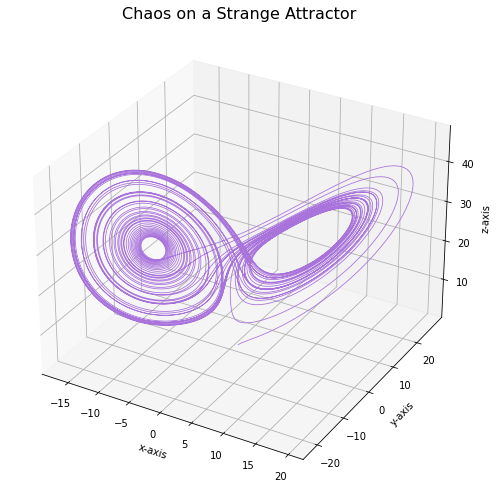

In [7]:
# plot the results
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

ax.plot(solution.y[0], solution.y[1], solution.y[2], 
        lw=0.8, color="#A973DC")
#labels and title
ax.set_title("Chaos on a Strange Attractor", fontsize=16)
ax.set_xlabel("x-axis")
ax.set_ylabel("y-axis")
ax.set_zlabel("z-axis")

plt.tight_layout()
plt.show()

Comments:

- This is the butterfly effect - and you can probably see why it was named that.

- The system is completely deterministic. The motion appears random but it is fully constructed by the Lorenz equations and standard initial conditions (**important:** in chaos theory it is almost impossible to measure the precise initial condition and as mentioned before the most infitimalistic change can make up a whole different outcome!).

- the trajectory never repeats itself and continuously moves around two unstable equilibrium regions (center of the "wings").

Conclusion: the model demonstrates deterministic systems can still become unpredictable over time (one of the key points in chaos theory).

## Analysing Sensitivity to Initial Conditions

We now establish how a chaotic systems is their extremely sensitive to initial conditions. We will demonstrate this by creating two Lorenz simulations with almost identical initial values:

```python
state0_a = [1.0, 1.0, 1.0]
state0_b = [1.0 + 0.0001, 1.0, 1.0]
```

The only difference between the two systems is a change of `0.0001` in the initial x-value. The systems are then solved numerically using `solve_ivp`.

We then calculate the Euclidean distance in phase spase to explore how fast the two trajectory seperates:
$$
d(t) = \sqrt{(x_1-x_2)^2 + (y_1-y_2)^2 + (z_1-z_2)^2}
$$
For a stable system the distance would remain small over time. But we know that in a chaotic system - like the Lorenz attractor, the distance grows exponentially.

In [ ]:
# first: we generate the two starting points with distance of 0.0001 in the euclidean space
state0_a = [1.0, 1.0, 1.0]
state0_b = [1.0 + 0.0001, 1.0, 1.0]

# Solve both
sol_a = solve_ivp(lorenz, t_span, state0_a, t_eval=t_eval)
sol_b = solve_ivp(lorenz, t_span, state0_b, t_eval=t_eval)

# Calculate the distance between the two trajectories over time
distance = np.sqrt((sol_a.y[0] - sol_b.y[0])**2 + 
                   (sol_a.y[1] - sol_b.y[1])**2 + 
                   (sol_a.y[2] - sol_b.y[2])**2)

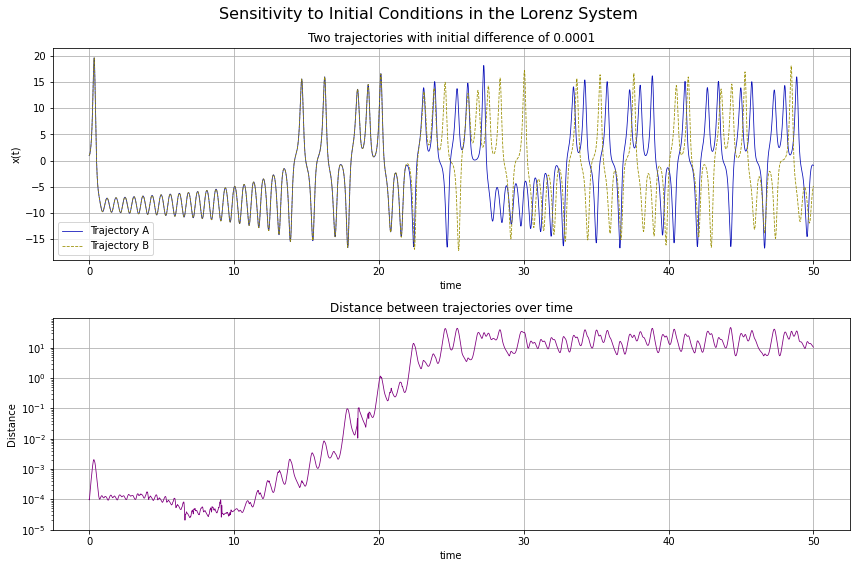

In [15]:
#plot the distance on log scale
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
title = "Sensitivity to Initial Conditions in the Lorenz System" 
fig.suptitle(title, fontsize=16)


# Top panel: x over time for both trajectories
axes[0].plot(t_eval, sol_a.y[0], color="#0C12B9", lw=0.8, label="Trajectory A")
axes[0].plot(t_eval, sol_b.y[0], color="#9A8F00", lw=0.8, label="Trajectory B", linestyle="--")
axes[0].set_title("Two trajectories with initial difference of 0.0001")
axes[0].set_xlabel("time")
axes[0].set_ylabel("x(t)")
axes[0].grid(True)
axes[0].legend()

# Bottom panel: distance between trajectories over time
axes[1].plot(t_eval, distance, color="#800080", lw=0.8)
axes[1].set_yscale("log")
axes[1].set_title("Distance between trajectories over time")
axes[1].set_xlabel("time")
axes[1].set_ylabel("Distance")
axes[1].grid(True)
plt.tight_layout()
plt.show()

Comments:

**Upper plot:** 
Two trajectories starting with initial conditions that differ by just 0.0001. 

- In the beginning they are virtually identical — the two curves overlap so closely you can barely tell them apart. 

- Around t = 15, they begin to separate, and by t = 25 they are evolving into completely different states.

**Lower plot:** 
The logarithm of the distance between the two trajectories. 

- The "diagonal" line in the middle of the simulation is the key result — on a log scale, a straight line means exponential growth.

- This is the mathematical signature of chaos, and it is directly related to the Lyapunov exponent.

Conclusion: Eventually the distance saturates — the two trajectories are now as far apart as the attractor allows, and any resemblance between them is gone. This is the forecast horizon: the point beyond which prediction becomes impossible, not because the equations are wrong, but because the atmosphere amplifies uncertainty faster than we can measure it.

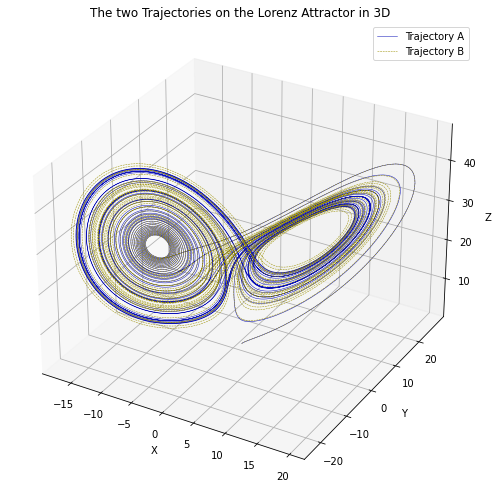

In [18]:
# 3D plot of the two trajectories
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

ax.plot(sol_a.y[0], sol_a.y[1], sol_a.y[2],
        lw=0.5, color="#0C12B9", label="Trajectory A")
ax.plot(sol_b.y[0], sol_b.y[1], sol_b.y[2],
        lw=0.5, color="#9A8F00", label="Trajectory B", linestyle="--")

ax.set_title("The two Trajectories on the Lorenz Attractor in 3D")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.legend()

plt.tight_layout()
plt.show()